<a href="https://colab.research.google.com/github/Sirigalla34/deep-learning-programs/blob/main/lstm_forward_and_backward_propogation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Epoch: 100
Loss: 3.246898
Epoch: 200
Loss: 1.643611
Epoch: 300
Loss: 0.22586
Epoch: 400
Loss: 0.097141
Epoch: 500
Loss: 0.06073
Epoch: 600
Loss: 0.043933
Epoch: 700
Loss: 0.034331
Epoch: 800
Loss: 0.028137
Epoch: 900
Loss: 0.023816
Epoch: 1000
Loss: 0.020635
Final loss: 0.020635
Final predictions:
[[0.  ]
 [0.99]
 [0.  ]]
[[0.01]
 [0.  ]
 [0.99]]
[[0.99]
 [0.  ]
 [0.  ]]


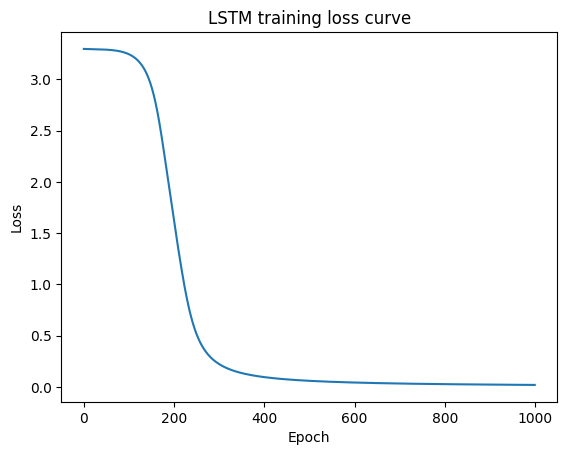

In [1]:
import numpy as np
import matplotlib.pyplot as plt
def sigmoid(x):
    return 1/(1+np.exp(-x))
def softmax(x):
    exp_x = np.exp(x-np.max(x))
    return exp_x/np.sum(exp_x)
def cross_entropy(y_true,y_pred):
    return -np.sum(y_true*np.log(y_pred+1e-12))
input_size = 3
hidden_size = 2
output_size = 3
def init_gate():
    return np.random.randn(hidden_size,input_size+hidden_size)*0.1
Wf = init_gate()
Wi = init_gate()
Wo = init_gate()
Wc = init_gate()
bf = np.zeros((hidden_size,1))
bi = np.zeros((hidden_size,1))
bo = np.zeros((hidden_size,1))
bc = np.zeros((hidden_size,1))
Why = np.random.randn(output_size,hidden_size)*0.1
by = np.zeros((output_size,1))
x1 = np.array([[1],[0],[0]])
x2 = np.array([[0],[1],[0]])
x3 = np.array([[0],[0],[1]])
inputs = [x1,x2,x3]
t1 = np.array([[0],[1],[0]])
t2 = np.array([[0],[0],[1]])
t3 = np.array([[1],[0],[0]])
targets = [t1,t2,t3]
learning_rate = 0.1
epochs = 1000
loss_history = []
for epoch in range(epochs):
    h = np.zeros((hidden_size,1))
    c = np.zeros((hidden_size,1))
    hs=[h]
    cs=[c]
    fs=[]
    isg=[]
    os=[]
    cts=[]
    ps=[]
    loss = 0
    for t in range(3):
        z = np.vstack((h,inputs[t]))
        f = sigmoid(Wf@z + bf)
        i = sigmoid(Wi@z + bi)
        o = sigmoid(Wo@z + bo)
        c_t = np.tanh(Wc@z + bc)
        c = f*c + i*c_t
        h = o*np.tanh(c)
        y = Why@h + by
        p = softmax(y)
        loss += cross_entropy(targets[t],p)
        hs.append(h)
        cs.append(c)
        fs.append(f)
        isg.append(i)
        os.append(o)
        cts.append(c_t)
        ps.append(p)
    loss_history.append(loss)
    dWf=np.zeros_like(Wf)
    dWi=np.zeros_like(Wi)
    dWo=np.zeros_like(Wo)
    dWc=np.zeros_like(Wc)
    dbf=np.zeros_like(bf)
    dbi=np.zeros_like(bi)
    dbo=np.zeros_like(bo)
    dbc=np.zeros_like(bc)
    dWhy=np.zeros_like(Why)
    dby=np.zeros_like(by)
    dh_next=np.zeros((hidden_size,1))
    dc_next=np.zeros((hidden_size,1))
    for t in reversed(range(3)):
        dy = ps[t] - targets[t]
        dWhy += dy @ hs[t+1].T
        dby += dy
        dh = Why.T @ dy + dh_next
        c = cs[t+1]
        o = os[t]
        tanhc = np.tanh(c)
        do = dh * tanhc
        do_raw = do * o * (1-o)
        dc = dh*o*(1-tanhc**2) + dc_next
        f = fs[t]
        i = isg[t]
        c_t = cts[t]
        dc_t = dc*i
        dc_t_raw = dc_t*(1-c_t**2)
        di = dc*c_t
        di_raw = di*i*(1-i)
        c_prev = cs[t]
        df = dc*c_prev
        df_raw = df*f*(1-f)
        z = np.vstack((hs[t],inputs[t]))
        dWf += df_raw@z.T
        dWi += di_raw@z.T
        dWo += do_raw@z.T
        dWc += dc_t_raw@z.T
        dbf += df_raw
        dbi += di_raw
        dbo += do_raw
        dbc += dc_t_raw
        dz = Wf.T@df_raw + Wi.T@di_raw + Wo.T@do_raw + Wc.T@dc_t_raw
        dh_next = dz[:hidden_size,:]
        dc_next = dc*f
    Wf -= learning_rate*dWf
    Wi -= learning_rate*dWi
    Wo -= learning_rate*dWo
    Wc -= learning_rate*dWc
    Why -= learning_rate*dWhy
    bf -= learning_rate*dbf
    bi -= learning_rate*dbi
    bo -= learning_rate*dbo
    bc -= learning_rate*dbc
    by -= learning_rate*dby
    if (epoch+1)%100==0:
        print("Epoch:",epoch+1)
        print("Loss:",round(loss,6))
print("Final loss:",round(loss,6))
print("Final predictions:")
for p in ps:
    print(np.round(p,2))
plt.plot(loss_history)
plt.title("LSTM training loss curve")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.show()